<a href="https://colab.research.google.com/github/hohohoo07/Advanced_software_Lab./blob/main/AS_Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

원본 영상


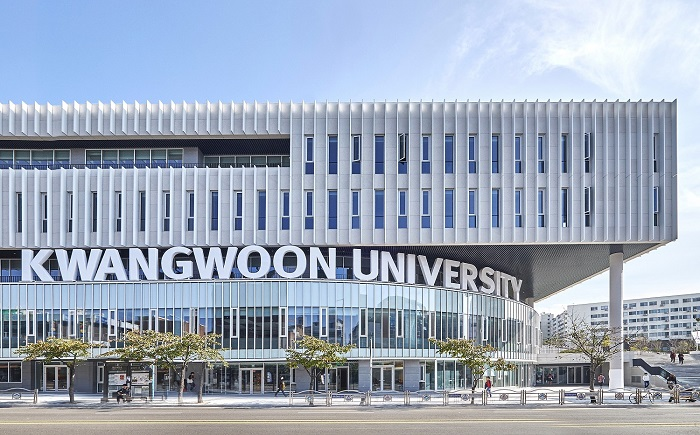

그레이스케일


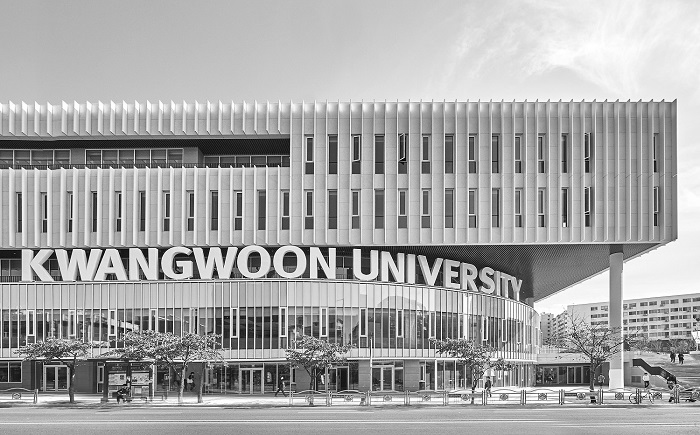

에지 검출 결과


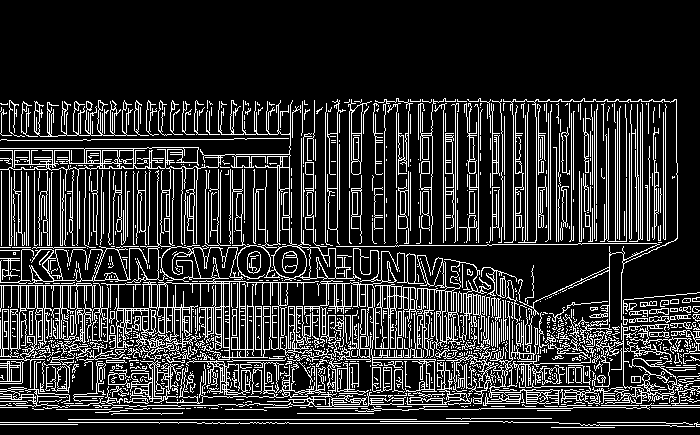

In [8]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 영상 불러오기
img = cv2.imread("campus.jpg")

# 2. 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Canny 에지 검출
edges = cv2.Canny(gray, 100, 200)

# 4. 결과 출력
print("원본 영상")
cv2_imshow(img)

print("그레이스케일")
cv2_imshow(gray)

print("에지 검출 결과")
cv2_imshow(edges)

윤곽선 1
면적: 78764.00
둘레: 1092.63
무게중심: (736, 732)
--------------------
윤곽선 2
면적: 79824.50
둘레: 1137.10
무게중심: (1224, 718)
--------------------
윤곽선 3
면적: 42296.00
둘레: 1443.94
무게중심: (258, 726)
--------------------
윤곽선 4
면적: 103832.00
둘레: 1330.83
무게중심: (751, 328)
--------------------
윤곽선 5
면적: 51471.50
둘레: 1081.90
무게중심: (1246, 353)
--------------------
윤곽선 6
면적: 81400.50
둘레: 1067.16
무게중심: (263, 312)
--------------------


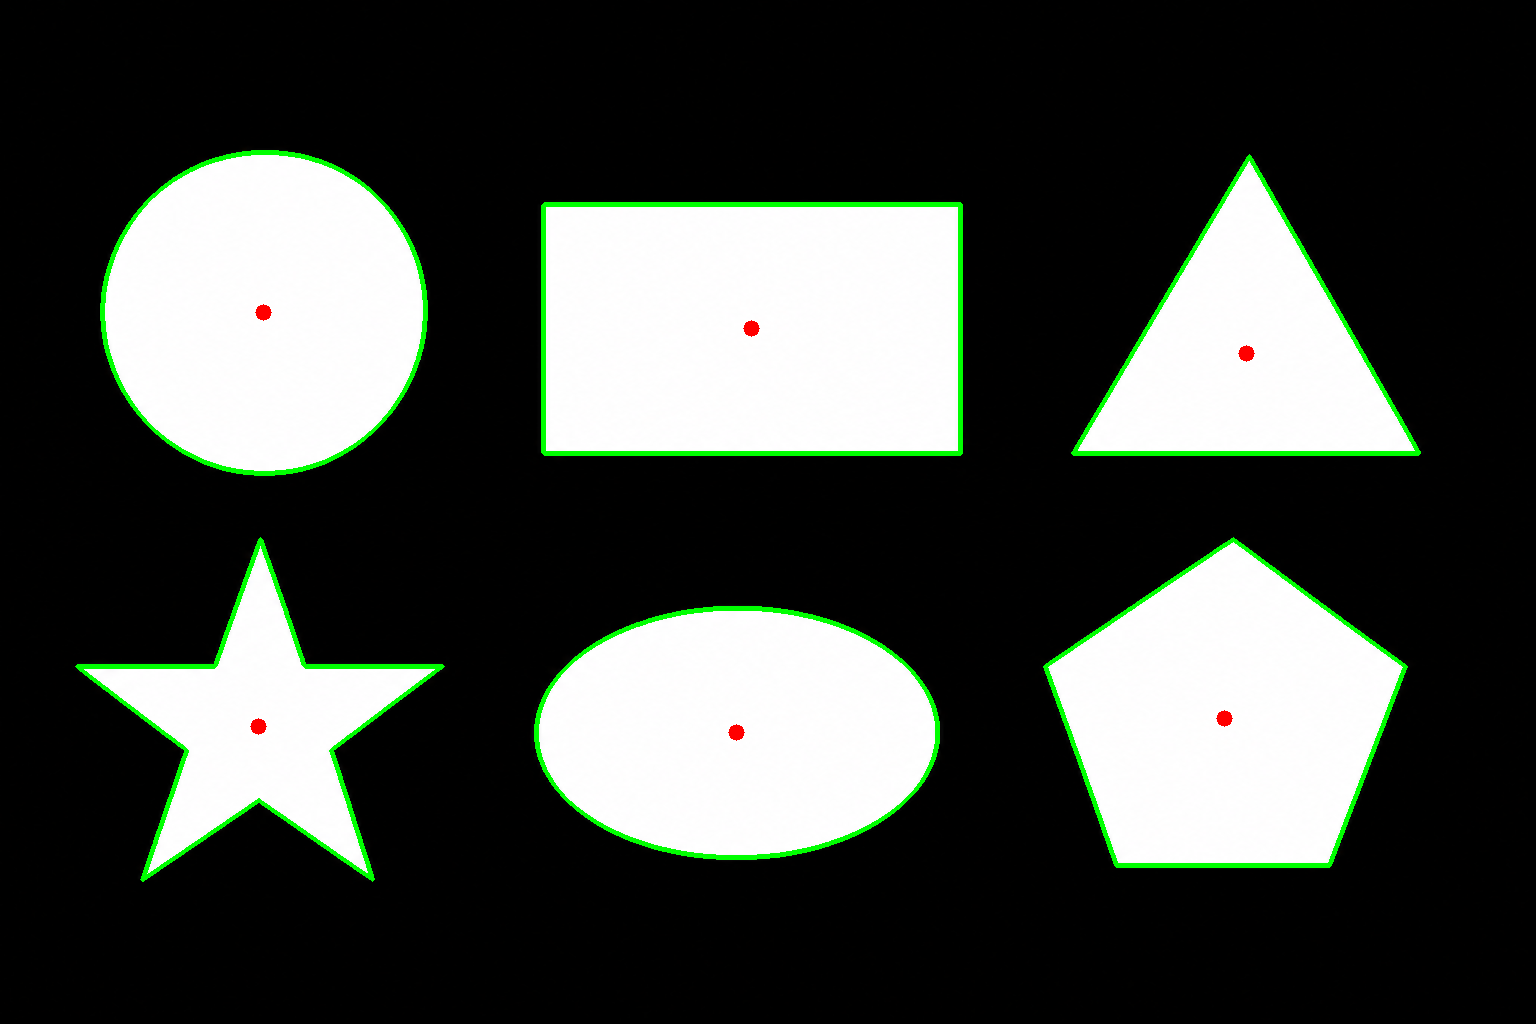

In [5]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 이미지 불러오기
img = cv2.imread("shapes.jpg")

# 2. 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. 이진화
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 4. 윤곽선 검출
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 5. 각 윤곽선의 특징값 계산
for i, cnt in enumerate(contours):

    # 면적
    area = cv2.contourArea(cnt)

    # 둘레
    peri = cv2.arcLength(cnt, True)

    # 무게중심
    M = cv2.moments(cnt)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        print(f"윤곽선 {i + 1}")
        print(f"면적: {area:.2f}")
        print(f"둘레: {peri:.2f}")
        print(f"무게중심: ({cx}, {cy})")
        print("--------------------")

        # 무게중심을 빨간 점으로 표시
        cv2.circle(img, (cx, cy), 8, (0, 0, 255), -1)

# 6. 모든 윤곽선을 초록색으로 표시
cv2.drawContours(img, contours, -1, (0, 255, 0), 3)

# 7. 결과 출력
cv2_imshow(img)

삼각형: 2 개
사각형: 3 개
원: 4 개


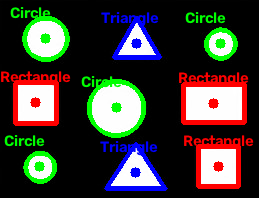

In [9]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 이미지 읽기
img = cv2.imread("shapes2.jpg")

# 원본 보존
result = img.copy()

# 2. 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. 이진화
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 4. 윤곽선 검출
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 도형 개수
triangle_count = 0
rectangle_count = 0
circle_count = 0

# 5. 각 윤곽선 분석
for cnt in contours:

    # 너무 작은 잡음 제거
    area = cv2.contourArea(cnt)
    if area < 500:
        continue

    # 윤곽선 둘레
    peri = cv2.arcLength(cnt, True)

    # 윤곽선 근사화
    approx = cv2.approxPolyDP(cnt, 0.04 * peri, True)

    # 무게중심 계산
    M = cv2.moments(cnt)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # 꼭짓점 개수로 도형 분류
        if len(approx) == 3:
            shape = "Triangle"
            triangle_count += 1
            color = (255, 0, 0)       # 파랑

        elif len(approx) == 4:
            shape = "Rectangle"
            rectangle_count += 1
            color = (0, 0, 255)       # 빨강

        else:
            shape = "Circle"
            circle_count += 1
            color = (0, 255, 0)       # 초록

        # 윤곽선 그리기
        cv2.drawContours(result, [cnt], -1, color, 3)

        # 중심점 표시
        cv2.circle(result, (cx, cy), 5, color, -1)

        # 도형 이름 표시
        cv2.putText(
            result,
            shape,
            (cx - 35, cy - 20),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

# 6. 개수 출력
print("삼각형:", triangle_count, "개")
print("사각형:", rectangle_count, "개")
print("원:", circle_count, "개")

# 7. 결과 이미지 출력
cv2_imshow(result)

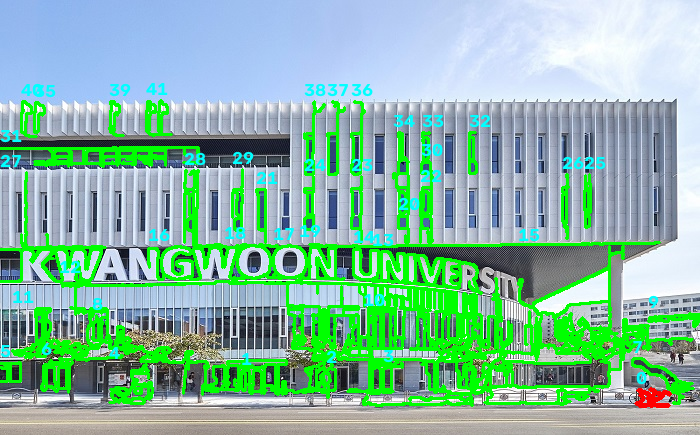

In [14]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 이미지 불러오기
img = cv2.imread("campus.jpg")
result = img.copy()

# 2. 그레이스케일
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. 가우시안 블러
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 4. Canny 에지 검출
edges = cv2.Canny(blur, 50, 150)

# 5. 윤곽선 검출
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 너무 작은 윤곽선만 제거
contours = [cnt for cnt in contours
            if cv2.contourArea(cnt) > 100]

# 6. 모든 윤곽선 → 초록색
cv2.drawContours(
    result,
    contours,
    -1,
    (0, 255, 0),
    2
)

# 7. 특정 윤곽선 하나 → 빨간색
if len(contours) > 0:
    cv2.drawContours(
        result,
        [contours[0]],
        -1,
        (0, 0, 255),
        3
    )

# 8. 각 윤곽선에 번호 표시
for i, cnt in enumerate(contours):
    x, y, w, h = cv2.boundingRect(cnt)

    cv2.putText(
        result,
        str(i),
        (x, y - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 0),
        2
    )

# 9. 결과 출력
cv2_imshow(result)

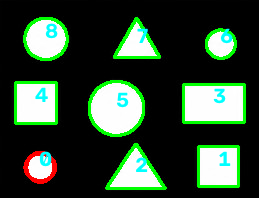

In [15]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 이미지 불러오기
img = cv2.imread("shapes2.jpg")

# 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 이진화
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 윤곽선 검출
contours, _ = cv2.findContours(
    binary,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 결과를 그릴 이미지 복사
result = img.copy()


# 2. 모든 윤곽선 그리기 - 초록색
cv2.drawContours(result, contours, -1, (0, 255, 0), 2)


# 3. 특정 윤곽선 강조 - 첫 번째 윤곽선을 빨간색으로
if len(contours) > 0:
    cv2.drawContours(result, [contours[0]], -1, (0, 0, 255), 3)


# 4. 각 윤곽선에 번호 표시
for i, cnt in enumerate(contours):

    M = cv2.moments(cnt)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        cv2.putText(
            result,
            str(i),
            (cx, cy),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 0),
            2
        )


# 결과 출력
cv2_imshow(result)

원본 이미지


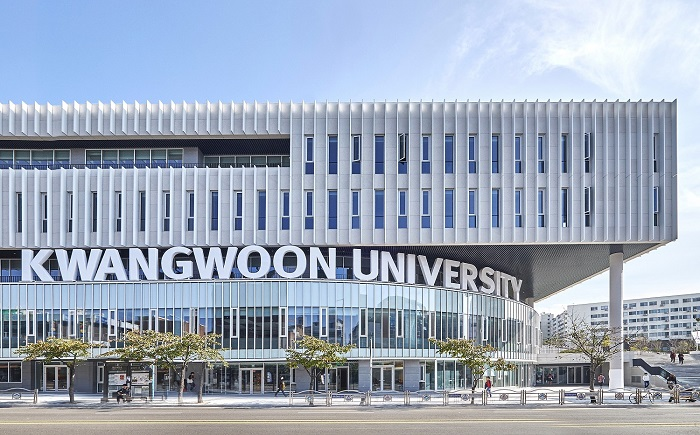

Canny 에지 검출 결과


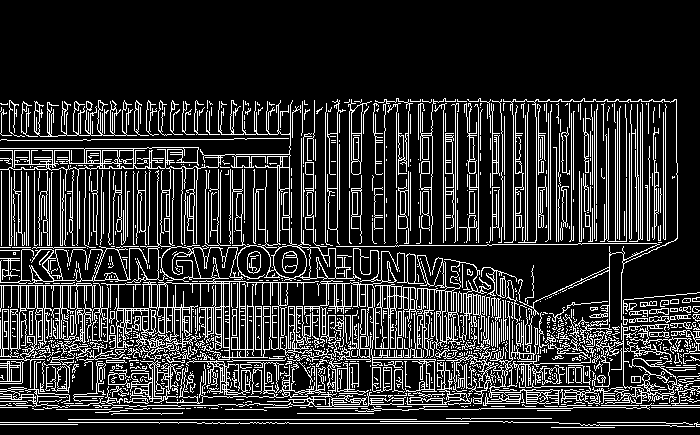

윤곽선 검출 결과


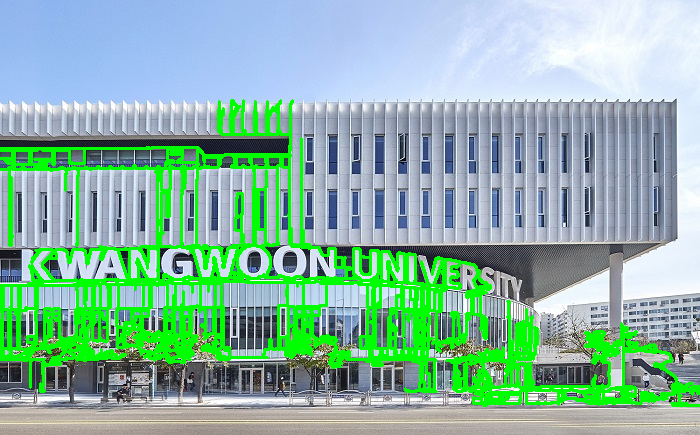

In [16]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 이미지 불러오기
img = cv2.imread("campus.jpg")

# 2. 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Canny 에지 검출
edges = cv2.Canny(gray, 100, 200)

# 4. 윤곽선 검출
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 결과를 그릴 이미지 복사
result = img.copy()

# 5. 일정 크기 이상의 윤곽선만 그리기
for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 1000:
        cv2.drawContours(
            result,
            [cnt],
            -1,
            (0, 255, 0),
            2
        )

# 6. 결과 확인
print("원본 이미지")
cv2_imshow(img)

print("Canny 에지 검출 결과")
cv2_imshow(edges)

print("윤곽선 검출 결과")
cv2_imshow(result)

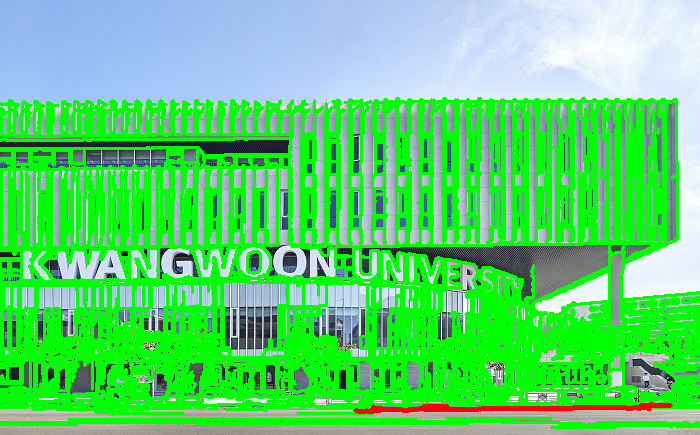

In [30]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("campus.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 0. 윤곽선 찾기(에지 검출, 검출된 에지에서 새로운 윤곽선 찾기)
edges = cv2.Canny(gray, 100, 200)
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 1. 모든 윤곽선 그리기 (초록색, 두께 2)
cv2.drawContours(img, contours, -1, (0, 255, 0), 2)

# 2. 특정 윤곽선만 선택해서 그리기 (예: i번째 윤곽선, 빨간색, 두께 3)
i = 50
cv2.drawContours(img, [contours[i]], -1, (0, 0, 255), 3)

# 3. 윤곽선 번호 표시하기
# for i, cnt in enumerate(contours):
#     x, y, w, h = cv2.boundingRect(cnt)
#     cv2.putText(img, str(i), (x, y - 5),
#                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255),2)
cv2_imshow(img)

원본 이미지


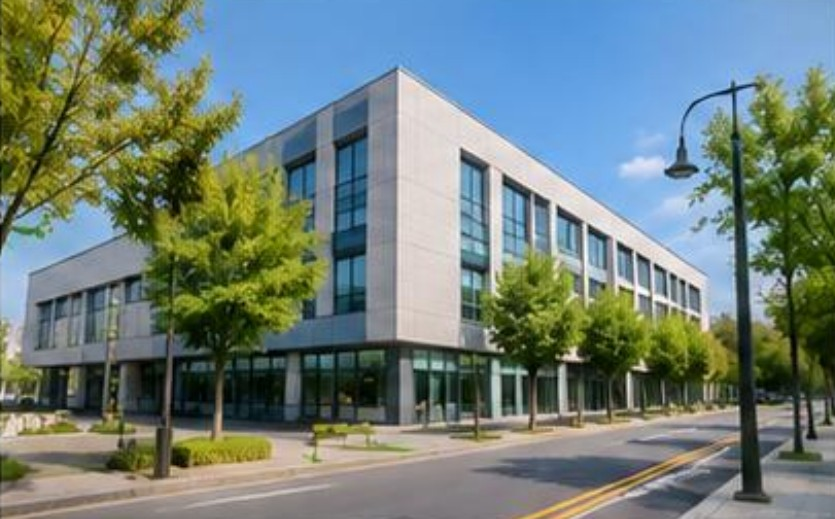

Canny 에지 검출 결과


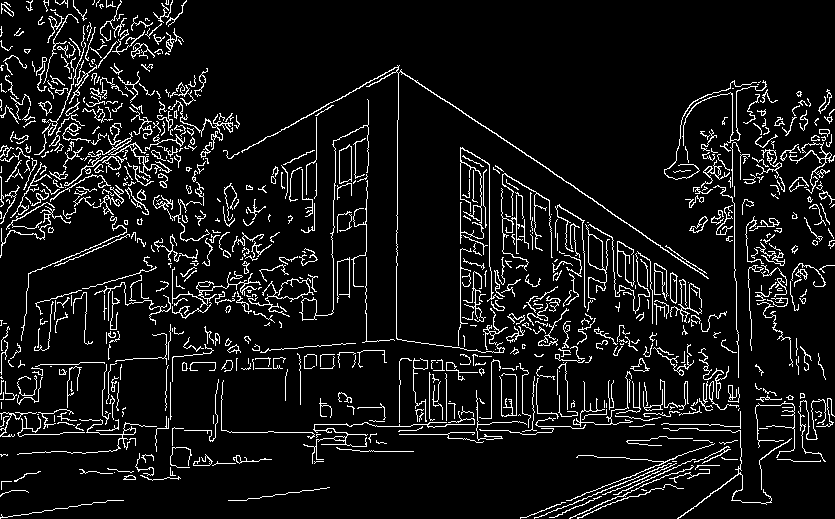

윤곽선 검출 결과


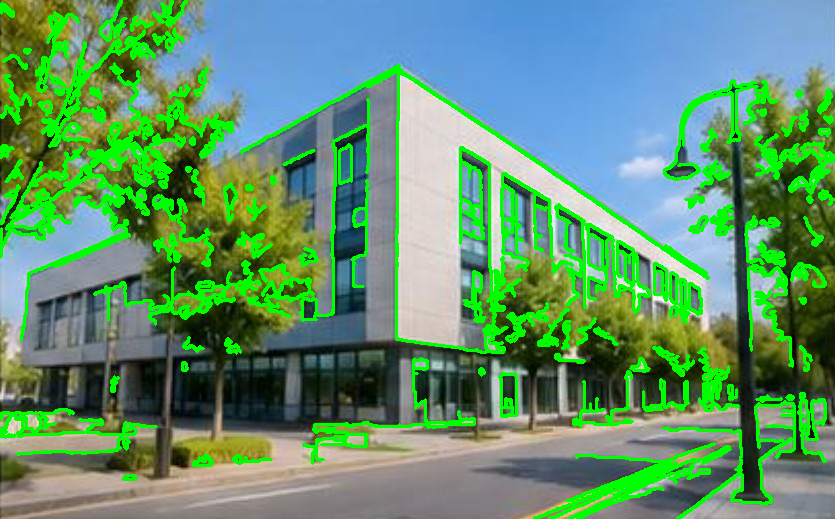

In [40]:
import cv2
from google.colab.patches import cv2_imshow

# 1. 이미지 불러오기
img = cv2.imread("building.jpg")

# 2. 그레이스케일 변환
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 3. Canny 에지 검출
edges = cv2.Canny(gray, 100, 200)

# 4. 윤곽선 검출
contours, _ = cv2.findContours(
    edges,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 결과를 그릴 이미지 복사
result = img.copy()

# 5. 일정 크기 이상의 윤곽선만 그리기
for cnt in contours:
    area = cv2.contourArea(cnt)

    if area > 10:
        cv2.drawContours(
            result,
            [cnt],
            -1,
            (0, 255, 0),
            2
        )

# 6. 결과 확인
print("원본 이미지")
cv2_imshow(img)

print("Canny 에지 검출 결과")
cv2_imshow(edges)

print("윤곽선 검출 결과")
cv2_imshow(result)

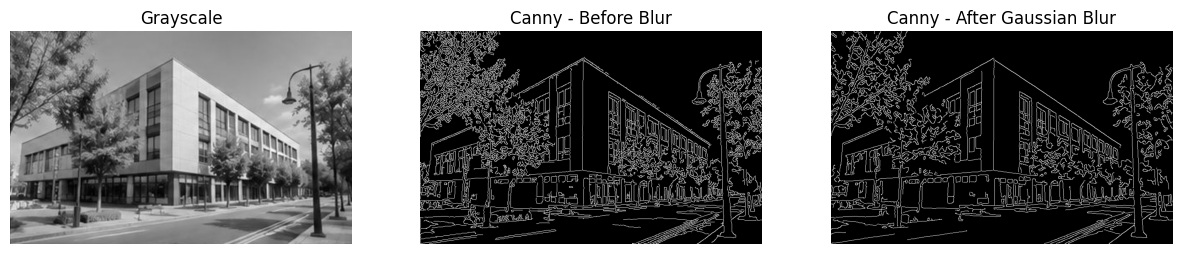

In [44]:
import cv2
import matplotlib.pyplot as plt

# 이미지 불러오기
img = cv2.imread("building.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 가우시안 블러
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 동일한 임계값 사용
t1, t2 = 50, 150

# 블러 적용 전 Canny
edges_before = cv2.Canny(gray, t1, t2)

# 블러 적용 후 Canny
edges_after = cv2.Canny(blur, t1, t2)

# 비교
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(edges_before, cmap="gray")
plt.title("Canny - Before Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges_after, cmap="gray")
plt.title("Canny - After Gaussian Blur")
plt.axis("off")

plt.show()

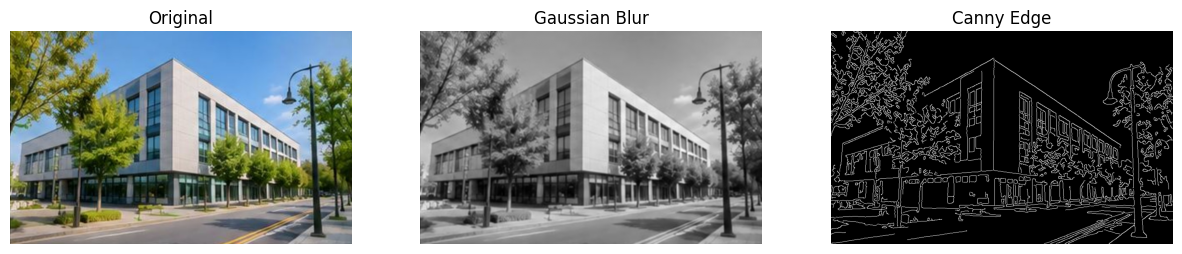

In [43]:
import cv2
import matplotlib.pyplot as plt

# 1. 이미지 읽기
img = cv2.imread("building.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. 가우시안 블러 적용
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Canny 에지 검출
t1, t2 = 50, 150
edges = cv2.Canny(blur, t1, t2)

# 4. 결과 표시
plt.figure(figsize=(15, 5))

# 원본 이미지
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

# 가우시안 블러
plt.subplot(1, 3, 2)
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

# Canny 에지 검출
plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge")
plt.axis("off")

plt.show()